# Real-Time Transport Operations Analytics (No Synthetic Data)

This notebook uses only live TfL APIs and Spark to build operational KPIs and visuals.

In [1]:
import os
import sys
from pathlib import Path
from pyspark.sql import SparkSession

# Resolve project root robustly for both workspace root and notebooks/ execution.
cwd = Path.cwd()
candidates = [cwd, cwd / "bigdata", cwd.parent]
project_root = None
for c in candidates:
    if (c / "src").exists():
        project_root = c
        break

if project_root is None:
    raise RuntimeError(f"Could not locate project root with src/ from cwd={cwd}")

# Ensure imports like `from src...` always work.
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

os.environ["JAVA_HOME"] = str(project_root / "jdk-17.0.2")
os.environ["HADOOP_HOME"] = str(project_root / "hadoop")
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

os.environ["PATH"] = (
    str(project_root / "jdk-17.0.2" / "bin")
    + os.pathsep
    + str(project_root / "hadoop" / "bin")
    + os.pathsep
    + os.environ.get("PATH", "")
)

spark = (
    SparkSession.builder
    .appName("TransportOpsRealAPI")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "4")
    .config("spark.pyspark.python", sys.executable)
    .config("spark.pyspark.driver.python", sys.executable)
    .config("spark.python.use.daemon", "false")
    .config("spark.driver.extraJavaOptions", "-Duser.name=notebook")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

print("Project root:", project_root)
print("Python:", sys.executable)
print("Spark Version:", spark.version)
print("Spark UI:", spark.sparkContext.uiWebUrl)

Project root: D:\python\bigdata
Python: D:\python\bigdata\.venv\Scripts\python.exe
Spark Version: 3.5.0
Spark UI: http://127.0.0.1:4041


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Keep notebook rendering deterministic and readable.
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Plotting stack ready.")

Plotting stack ready.


In [3]:
from datetime import datetime

def pandas_to_spark_via_csv(pdf, name_prefix="data"):
    root = project_root
    tmp_dir = root / "data" / "_tmp_real_api"
    tmp_dir.mkdir(parents=True, exist_ok=True)
    csv_path = tmp_dir / f"{name_prefix}_{datetime.now().strftime('%Y%m%d_%H%M%S_%f')}.csv"
    pdf.to_csv(csv_path, index=False)
    return spark.read.option("header", True).option("inferSchema", True).csv(str(csv_path))

In [4]:
# Fallback for out-of-order execution: ensure src imports resolve.
from pathlib import Path
import sys

if "project_root" not in globals():
    cwd = Path.cwd()
    candidates = [cwd, cwd / "bigdata", cwd.parent]
    project_root = next((c for c in candidates if (c / "src").exists()), None)
    if project_root is None:
        raise RuntimeError(f"Could not locate project root with src/ from cwd={cwd}")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_fetcher import UKGovDataFetcher

fetcher = UKGovDataFetcher()

traffic_pdf = fetcher.fetch_tfl_traffic_data()
line_pdf = fetcher.fetch_tfl_line_status()
bike_pdf = fetcher.fetch_tfl_bikepoint_status()

print("Traffic rows:", len(traffic_pdf))
print("Line status rows:", len(line_pdf))
print("BikePoint rows:", len(bike_pdf))

if not traffic_pdf.empty: display(traffic_pdf.head(5))
if not line_pdf.empty: display(line_pdf.head(5))
if not bike_pdf.empty: display(bike_pdf.head(5))

Traffic rows: 73
Line status rows: 11
BikePoint rows: 798


,disruption_id,category,severity,location,comments,last_modified,timestamp,data_source,endpoint_used
0,TIMS-206772,Works,Moderate,"[A12] EASTERN AVENUE EAST (RM2 ,RM3 ) (Havering)",Gallows Corner Flyover Refurbishment - [A12] E...,2026-04-12T03:34:31Z,2026-04-12T11:44:46.272253,TfL_RoadDisruption,https://api.tfl.gov.uk/Road/all/Disruption
1,TIMS-226852,Hazards,Moderate,"[A13] RIPPLE ROAD (IG11 ,RM9 ) (Barking & Dage...",[A13] Ripple Road (Westbound) at the junction ...,2026-04-12T03:44:01Z,2026-04-12T11:44:46.272253,TfL_RoadDisruption,https://api.tfl.gov.uk/Road/all/Disruption
2,TIMS-223032,Works,Moderate,[A1205] BURDETT ROAD (E14 ) (Tower Hamlets),[A1205] Burdett Road (Both directions) at the ...,2026-04-10T13:44:47Z,2026-04-12T11:44:46.272253,TfL_RoadDisruption,https://api.tfl.gov.uk/Road/all/Disruption
3,TIMS-225525,Network delays,Moderate,[A2204] FERRY APPROACH (SE18 ) (Greenwich),Woolwich Ferry One Boat Service - Woolwich Fer...,2026-04-12T05:08:44Z,2026-04-12T11:44:46.272253,TfL_RoadDisruption,https://api.tfl.gov.uk/Road/all/Disruption
4,TIMS-226212,Works,Moderate,[A205] WALDRAM CRESCENT (SE23 ) (Lewisham),[A205] Waldram Crescent (All directions) at th...,2026-04-12T03:36:51Z,2026-04-12T11:44:46.272253,TfL_RoadDisruption,https://api.tfl.gov.uk/Road/all/Disruption


,line_id,line_name,status,timestamp,data_source
0,bakerloo,Bakerloo,Good Service,2026-04-12T11:44:46.982164,TfL_LineStatus
1,central,Central,Good Service,2026-04-12T11:44:46.982164,TfL_LineStatus
2,circle,Circle,Part Closure,2026-04-12T11:44:46.982164,TfL_LineStatus
3,district,District,Part Closure,2026-04-12T11:44:46.982164,TfL_LineStatus
4,hammersmith-city,Hammersmith & City,Good Service,2026-04-12T11:44:46.982164,TfL_LineStatus


,bikepoint_id,name,lat,lon,bikes_available,empty_docks,docks_total,install_date,locked,temporary,timestamp,data_source
0,BikePoints_1,"River Street , Clerkenwell",51.529163,-0.109970,2,14,19,1278947280000,false,false,2026-04-12T11:44:47.916447,TfL_BikePoint
1,BikePoints_2,"Phillimore Gardens, Kensington",51.499606,-0.197574,12,24,37,1278585780000,false,false,2026-04-12T11:44:47.916447,TfL_BikePoint
2,BikePoints_3,"Christopher Street, Liverpool Street",51.521283,-0.084605,10,22,32,1278240360000,false,false,2026-04-12T11:44:47.916447,TfL_BikePoint
3,BikePoints_4,"St. Chad's Street, King's Cross",51.530059,-0.120973,21,0,23,1278241080000,false,false,2026-04-12T11:44:47.916447,TfL_BikePoint
4,BikePoints_5,"Sedding Street, Sloane Square",51.493130,-0.156876,8,16,27,1278241440000,false,false,2026-04-12T11:44:47.916447,TfL_BikePoint


In [5]:
traffic_df = pandas_to_spark_via_csv(traffic_pdf, "traffic") if not traffic_pdf.empty else None
line_df = pandas_to_spark_via_csv(line_pdf, "line") if not line_pdf.empty else None
bike_df = pandas_to_spark_via_csv(bike_pdf, "bike") if not bike_pdf.empty else None

if bike_df is not None:
    from pyspark.sql.functions import col
    bike_df = (
        bike_df
        .withColumn("bikes_available", col("bikes_available").cast("int"))
        .withColumn("empty_docks", col("empty_docks").cast("int"))
        .withColumn("docks_total", col("docks_total").cast("int"))
    )

print("Spark Traffic rows:", traffic_df.count() if traffic_df is not None else 0)
print("Spark Line rows:", line_df.count() if line_df is not None else 0)
print("Spark Bike rows:", bike_df.count() if bike_df is not None else 0)

Spark Traffic rows: 74
Spark Line rows: 11
Spark Bike rows: 798


In [6]:
from pyspark.sql.functions import count, desc

if traffic_df is not None:
    traffic_kpi = traffic_df.groupBy("severity").agg(count("*").alias("incidents")).orderBy(desc("incidents"))
    print("Traffic KPI (incidents by severity):")
    traffic_kpi.show(truncate=False)

if line_df is not None:
    line_kpi = line_df.groupBy("status").agg(count("*").alias("line_count")).orderBy(desc("line_count"))
    print("Line KPI (line count by status):")
    line_kpi.show(truncate=False)

if bike_df is not None:
    low_bike = bike_df.orderBy("bikes_available").select("name", "bikes_available", "docks_total").limit(15)
    print("Bike KPI (lowest bike availability):")
    low_bike.show(truncate=False)

Traffic KPI (incidents by severity):
+------------------------------------------------------------------------------------+---------+
|severity                                                                            |incidents|
+------------------------------------------------------------------------------------+---------+
|Minimal                                                                             |52       |
|Moderate                                                                            |21       |
| to facilitate reconstructing and resurfacing. From 24 April 22:00 to 26 April 05:00|1        |
+------------------------------------------------------------------------------------+---------+

Line KPI (line count by status):
+---------------+----------+
|status         |line_count|
+---------------+----------+
|Good Service   |8         |
|Part Closure   |2         |
|Planned Closure|1         |
+---------------+----------+

Bike KPI (lowest bike availability):
+--------

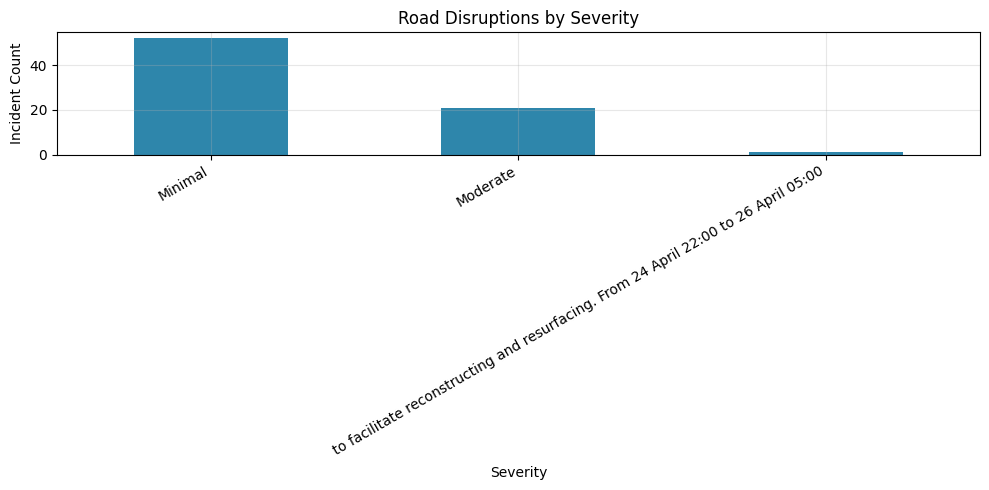

In [7]:
# Visual 1: Road disruption severity distribution
if traffic_df is not None and traffic_df.count() > 0:
    sev_pdf = (
        traffic_df.groupBy("severity")
        .count()
        .orderBy("count", ascending=False)
        .toPandas()
    )

    ax = sev_pdf.plot(kind="bar", x="severity", y="count", legend=False, color="#2E86AB")
    ax.set_title("Road Disruptions by Severity")
    ax.set_xlabel("Severity")
    ax.set_ylabel("Incident Count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No traffic data available for Visual 1.")

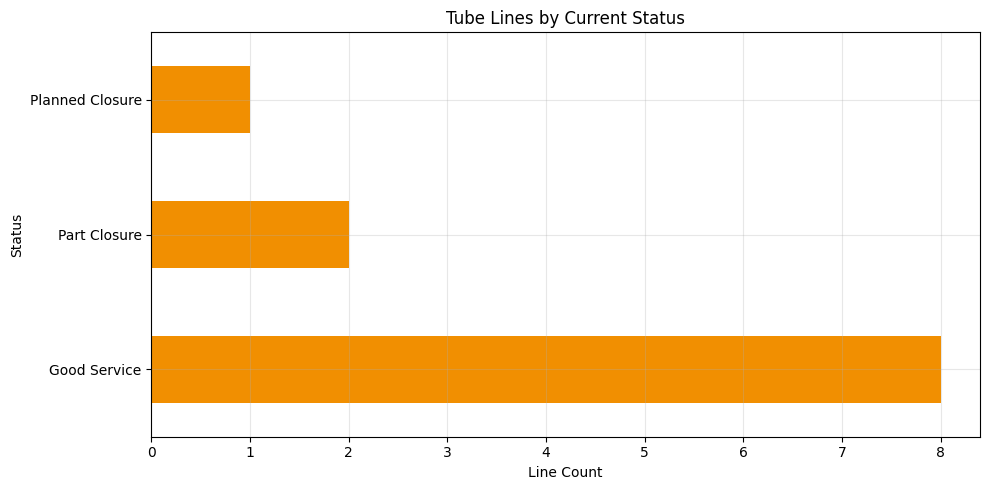

In [8]:
# Visual 2: Tube line status distribution
if line_df is not None and line_df.count() > 0:
    line_pdf_plot = (
        line_df.groupBy("status")
        .count()
        .orderBy("count", ascending=False)
        .toPandas()
    )

    ax = line_pdf_plot.plot(kind="barh", x="status", y="count", legend=False, color="#F18F01")
    ax.set_title("Tube Lines by Current Status")
    ax.set_xlabel("Line Count")
    ax.set_ylabel("Status")
    plt.tight_layout()
    plt.show()
else:
    print("No line status data available for Visual 2.")

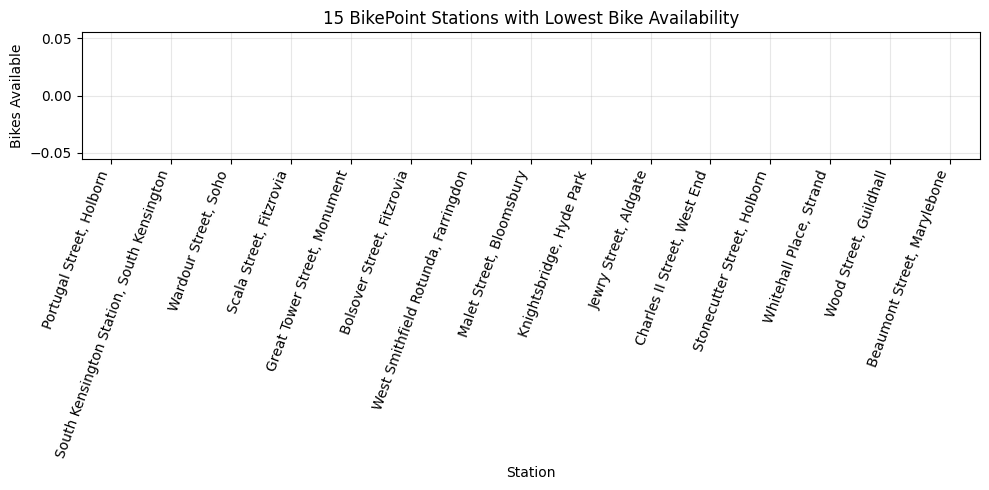

In [9]:
# Visual 3: Lowest bike availability stations
if bike_df is not None and bike_df.count() > 0:
    bike_low_pdf = (
        bike_df.select("name", "bikes_available")
        .orderBy("bikes_available")
        .limit(15)
        .toPandas()
    )

    ax = bike_low_pdf.plot(kind="bar", x="name", y="bikes_available", legend=False, color="#C73E1D")
    ax.set_title("15 BikePoint Stations with Lowest Bike Availability")
    ax.set_xlabel("Station")
    ax.set_ylabel("Bikes Available")
    plt.xticks(rotation=70, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No bike data available for Visual 3.")

In [10]:
# Real-time health check and executive summary
health = fetcher.check_tfl_realtime_health(polls=2, interval_seconds=5)
display(health)

delayed_lines = 0
if line_df is not None:
    delayed_lines = line_df.filter(~line_df.status.isin(["Good Service", "Planned Closure"])) .count()

print("\n=== EXECUTIVE SUMMARY ===")
print(f"Road disruptions (live): {traffic_df.count() if traffic_df is not None else 0}")
print(f"Tube lines reporting delays/disruptions: {delayed_lines}")
print(f"BikePoint stations monitored: {bike_df.count() if bike_df is not None else 0}")
print(f"Spark UI URL: {spark.sparkContext.uiWebUrl}")

,poll,poll_time,traffic_rows,line_rows,traffic_signature,line_signature,traffic_changed_since_first,line_status_changed_since_first
0,1,2026-04-12T11:45:09.743734,73,11,TIMS-200007|TIMS-204461|TIMS-206772|TIMS-21389...,Bakerloo:Good Service|Central:Good Service|Cir...,False,False
1,2,2026-04-12T11:45:16.133445,73,11,TIMS-200007|TIMS-204461|TIMS-206772|TIMS-21389...,Bakerloo:Good Service|Central:Good Service|Cir...,False,False



=== EXECUTIVE SUMMARY ===
Road disruptions (live): 74
Tube lines reporting delays/disruptions: 2
BikePoint stations monitored: 798
Spark UI URL: http://127.0.0.1:4041


In [11]:
# Optional: persist curated outputs for BI/reporting
out_dir = project_root / "data" / "curated"
out_dir.mkdir(parents=True, exist_ok=True)

if traffic_df is not None:
    traffic_df.write.mode("overwrite").parquet(str(out_dir / "traffic_disruptions"))
if line_df is not None:
    line_df.write.mode("overwrite").parquet(str(out_dir / "tube_status"))
if bike_df is not None:
    bike_df.write.mode("overwrite").parquet(str(out_dir / "bikepoint_status"))

print("Curated parquet datasets written to:", out_dir)

Curated parquet datasets written to: D:\python\bigdata\data\curated


## Executive Operations Scorecard\nOne-table summary of real-time transport operational risk signals.

In [12]:
from pyspark.sql.functions import col, when, avg

traffic_score = 0.0
traffic_total = 0
if traffic_df is not None and traffic_df.count() > 0:
    t = (
        traffic_df
        .withColumn(
            "sev_weight",
            when(col("severity") == "Severe", 3.0)
            .when(col("severity") == "Serious", 2.0)
            .when(col("severity") == "Moderate", 1.5)
            .when(col("severity") == "Minor", 1.0)
            .when(col("severity") == "Minimal", 0.5)
            .otherwise(0.5)
        )
    )
    traffic_total = t.count()
    traffic_score = t.agg(avg("sev_weight")).collect()[0][0] or 0.0

line_total = 0
line_delayed = 0
if line_df is not None and line_df.count() > 0:
    line_total = line_df.count()
    line_delayed = line_df.filter(~col("status").isin("Good Service", "Planned Closure")).count()

bike_total = 0
bike_low = 0
bike_stress_pct = 0.0
if bike_df is not None and bike_df.count() > 0:
    bike_total = bike_df.count()
    bike_low = bike_df.filter(col("bikes_available") <= 3).count()
    bike_stress_pct = (bike_low / bike_total) * 100 if bike_total else 0.0

line_delay_pct = (line_delayed / line_total) * 100 if line_total else 0.0

scorecard = pd.DataFrame([
    {
        "timestamp": datetime.now().isoformat(),
        "road_disruption_count": traffic_total,
        "road_disruption_severity_index": round(float(traffic_score), 2),
        "tube_lines_total": line_total,
        "tube_lines_delayed": line_delayed,
        "tube_delay_rate_pct": round(float(line_delay_pct), 2),
        "bike_stations_total": bike_total,
        "bike_stations_low_supply": bike_low,
        "bike_stress_rate_pct": round(float(bike_stress_pct), 2),
    }
])

display(scorecard)

print("\nInterpretation:")
print("- Higher road_disruption_severity_index means worse disruption quality mix.")
print("- Higher tube_delay_rate_pct means more lines in delayed/non-good state.")
print("- Higher bike_stress_rate_pct means more bike stations with critically low bikes.")

,timestamp,road_disruption_count,road_disruption_severity_index,tube_lines_total,tube_lines_delayed,tube_delay_rate_pct,bike_stations_total,bike_stations_low_supply,bike_stress_rate_pct
0,2026-04-12T11:45:21.857821,74,0.78,11,2,18.18,798,204,25.56



Interpretation:
- Higher road_disruption_severity_index means worse disruption quality mix.
- Higher tube_delay_rate_pct means more lines in delayed/non-good state.
- Higher bike_stress_rate_pct means more bike stations with critically low bikes.
